In this notebook, we compare our previous best loss function (Proxy Anchor Loss) with a combined loss from Proxy Anchor Loss and Center loss.

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "scheduler"
RANDOM_SEED = 234 # 34, 46, 78, 98, 234

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv

import torch
from torch.utils.data import DataLoader
import numpy as np
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    get_embeddings, extract_embeddings,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.criterions import CombinedLoss, CenterLoss, ProxyAnchorLoss
from src.models import EmbeddingProjection
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.training import train_loop
from src.visualization import visualize_embeddings_mds, plot_history

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 234 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,

    # Optimizer
    "weight_decay": 0.01,
    
    # StepLR
    "steplr_init_learning_rate": 1e-2,
    "steplr_step_size": 10,
    "steplr_gamma": 0.1,
    
    # CosineAnnealingLR
    "cosine_annealing_init_learning_rate": 5e-3,
    "cosine_annealing_eta_min": 1e-5,
    
    # ReduceLROnPlateau
    "reduce_lr_on_plateau_init_learning_rate": 1e-4,
    "reduce_lr_on_plateau_factor": 0.5,
    "reduce_lr_on_plateau_patience": 5,
    
    # ExponentialLR
    "exponential_lr_init_learning_rate": 1e-2,
    "exponential_lr_gamma": 0.95,
    
    # OneCycleLR
    "one_cycle_init_learning_rate": 5e-5,
    "one_cycle_max_learning_rate": 1e-3,
    "one_cycle_pct_start": 0.3,

    # Training
    "batch_size": 32,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  weight_decay: 0.01
  steplr_init_learning_rate: 0.01
  steplr_step_size: 10
  steplr_gamma: 0.1
  cosine_annealing_init_learning_rate: 0.005
  cosine_annealing_eta_min: 1e-05
  reduce_lr_on_plateau_init_learning_rate: 0.0001
  reduce_lr_on_plateau_factor: 0.5
  reduce_lr_on_plateau_patience: 5
  exponential_lr_init_learning_rate: 0.01
  exponential_lr_gamma: 0.95
  one_cycle_init_learning_rate: 5e-05
  one_cycle_max_learning_rate: 0.001
  one_cycle_pct_start: 0.3
  batch_size: 32
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 234


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


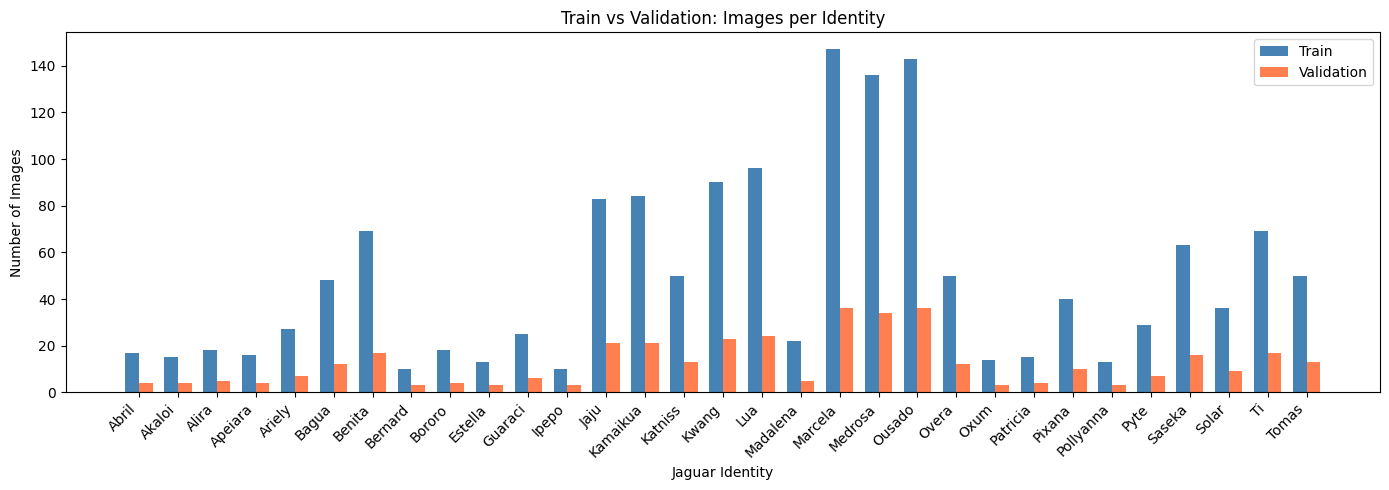


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using num_workers=8 for DataLoader


In [9]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [10]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [11]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [12]:
image_dataset = BlurImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [13]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader,
    filenames,
    device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


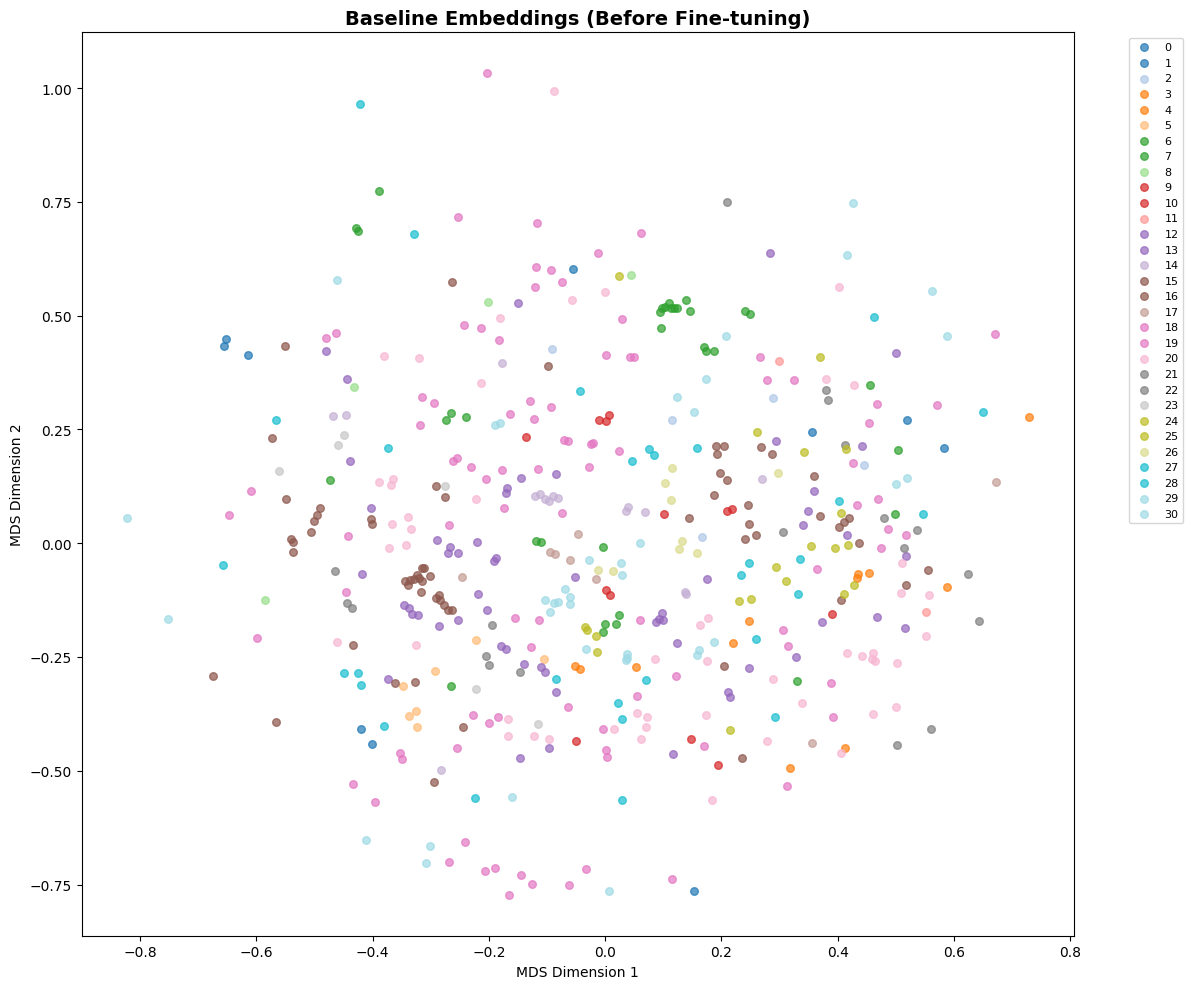

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/scheduler/model_initial_weights.pth


In [18]:
criterion = CombinedLoss(
    first_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    second_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

In [19]:
table = [
    ["Optimizer", "Best val_mAP", "Best epoch"]
]

## StepLR

In [20]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["steplr_init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config["steplr_step_size"],
    gamma=config["steplr_gamma"],
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: AdamW (lr={config['steplr_init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: StepLR (step_size={config['steplr_step_size']}, gamma={config['steplr_gamma']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: AdamW (lr=0.01, weight_decay=0.01)
  Scheduler: StepLR (step_size=10, gamma=0.1)


In [21]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_steplr_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="steplr",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_steplr": best_map,
    "best_epoch_steplr": best_epoch,
    "total_epochs_steplr": len(history['train_loss']),
})

table.append([
    "StepLR",
    best_map,
    best_epoch
])

All random seeds set to 234 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.8605
  Val Loss:   3.4537
  Val mAP:    0.2838 | LR: 1.00e-02
  [New best model saved]

Epoch 2/200


  Train Loss: 3.6910
  Val Loss:   1.6565
  Val mAP:    0.4976 | LR: 1.00e-02
  [New best model saved]

Epoch 3/200


  Train Loss: 2.4509
  Val Loss:   1.3336
  Val mAP:    0.6420 | LR: 1.00e-02
  [New best model saved]

Epoch 4/200


  Train Loss: 1.8735
  Val Loss:   1.2216
  Val mAP:    0.7824 | LR: 1.00e-02
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1493
  Val Loss:   0.6757
  Val mAP:    0.8956 | LR: 1.00e-05
  No improvement. Patience: 6/10

Epoch 37/200


  Train Loss: 0.1673
  Val Loss:   0.6679
  Val mAP:    0.8963 | LR: 1.00e-05
  No improvement. Patience: 7/10

Epoch 38/200


  Train Loss: 0.1583
  Val Loss:   0.6780
  Val mAP:    0.8969 | LR: 1.00e-05
  No improvement. Patience: 8/10

Epoch 39/200


  Train Loss: 0.1518
  Val Loss:   0.6796
  Val mAP:    0.8952 | LR: 1.00e-05
  No improvement. Patience: 9/10

Epoch 40/200


  Train Loss: 0.1581
  Val Loss:   0.6747
  Val mAP:    0.8961 | LR: 1.00e-06
  No improvement. Patience: 10/10

Early stopping triggered after 40 epochs

Training complete!
Best epoch: 30, Val mAP: 0.8984


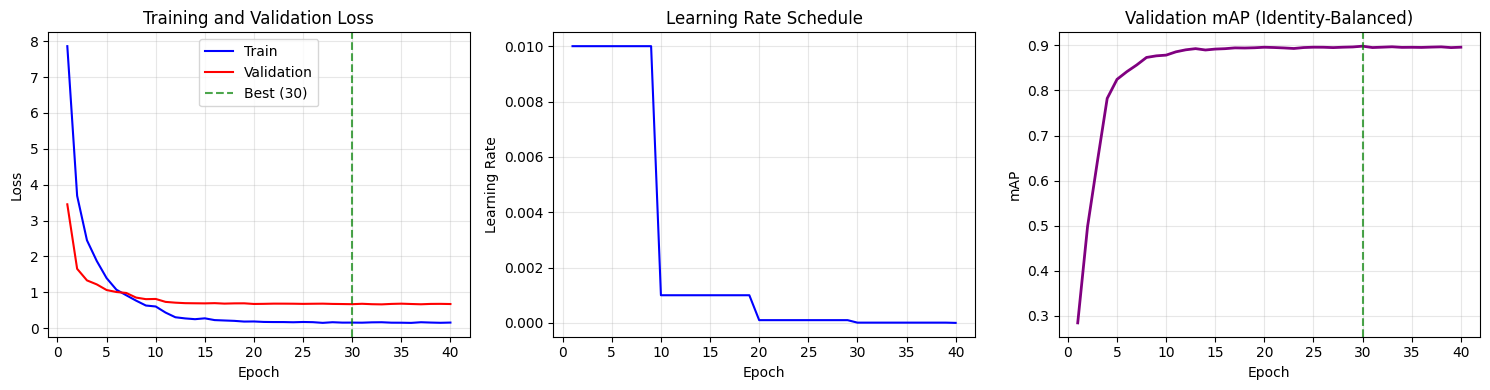

In [22]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_steplr.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_steplr": wandb.Image(fig)})

In [23]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 30
  Val Loss: 0.6706
  Val mAP: 0.8984


In [24]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


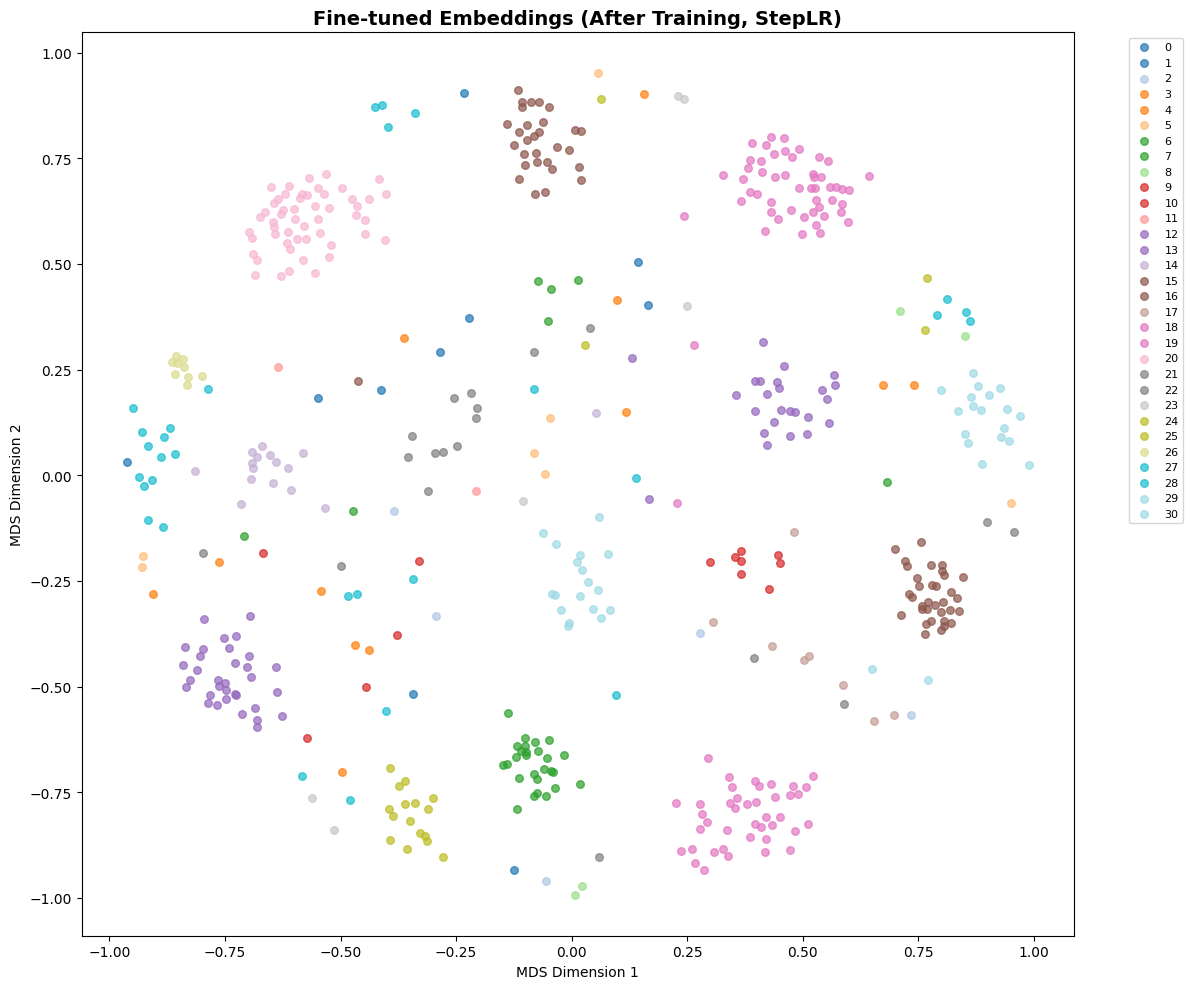

In [25]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, StepLR)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "steplr_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_steplr": wandb.Image(fig_finetuned)})

In [26]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## CosineAnnealingLR

In [27]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["cosine_annealing_init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["cosine_annealing_eta_min"]
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['cosine_annealing_init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']})")

Training components initialized:
  Optimizer: AdamW (lr=0.005, weight_decay=0.01)
  Scheduler: CosineAnnealingLR (T_max=200)


In [28]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_cosineannealinglr_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="cosineannealinglr",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_cosineannealinglr": best_map,
    "best_epoch_cosineannealinglr": best_epoch,
    "total_epochs_cosineannealinglr": len(history['train_loss']),
})

table.append([
    "CosineAnnealingLR",
    best_map,
    best_epoch
])

All random seeds set to 234 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.5027
  Val Loss:   3.3799
  Val mAP:    0.3021 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 3.6995
  Val Loss:   1.5196
  Val mAP:    0.5091 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.2393
  Val Loss:   1.2701
  Val mAP:    0.6446 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.6686
  Val Loss:   1.1017
  Val mAP:    0.7359 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.3141
  Val Loss:   0.7012
  Val mAP:    0.8981 | LR: 4.94e-03
  No improvement. Patience: 6/10

Epoch 15/200


  Train Loss: 0.3175
  Val Loss:   0.7201
  Val mAP:    0.8964 | LR: 4.93e-03
  No improvement. Patience: 7/10

Epoch 16/200


  Train Loss: 0.2874
  Val Loss:   0.7143
  Val mAP:    0.8993 | LR: 4.92e-03
  No improvement. Patience: 8/10

Epoch 17/200


  Train Loss: 0.2668
  Val Loss:   0.7231
  Val mAP:    0.9024 | LR: 4.91e-03
  No improvement. Patience: 9/10

Epoch 18/200


  Train Loss: 0.2677
  Val Loss:   0.6919
  Val mAP:    0.8988 | LR: 4.90e-03
  No improvement. Patience: 10/10

Early stopping triggered after 18 epochs

Training complete!
Best epoch: 8, Val mAP: 0.9027


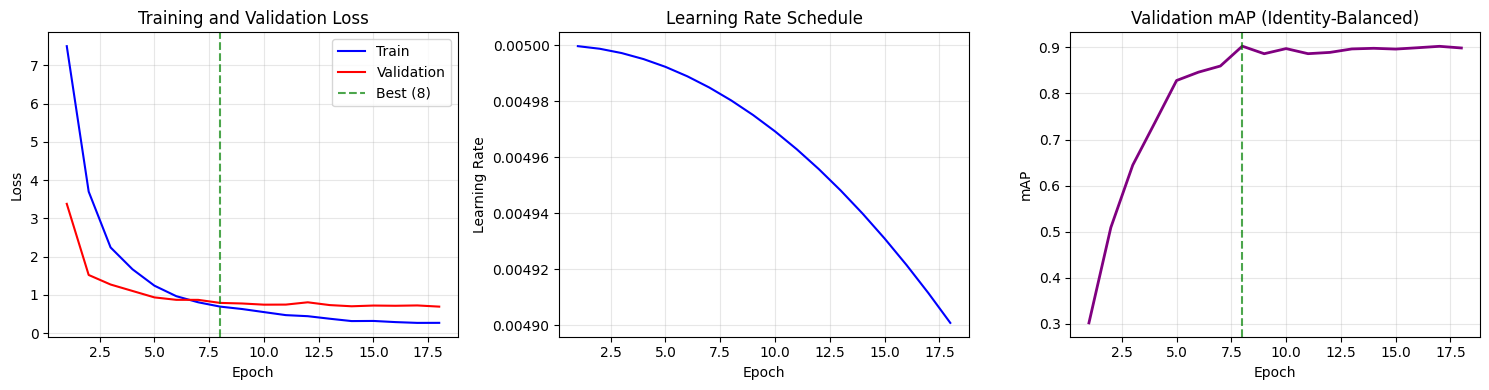

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_cosineannealinglr.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_cosineannealinglr": wandb.Image(fig)})

In [30]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 8
  Val Loss: 0.7893
  Val mAP: 0.9027


In [31]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


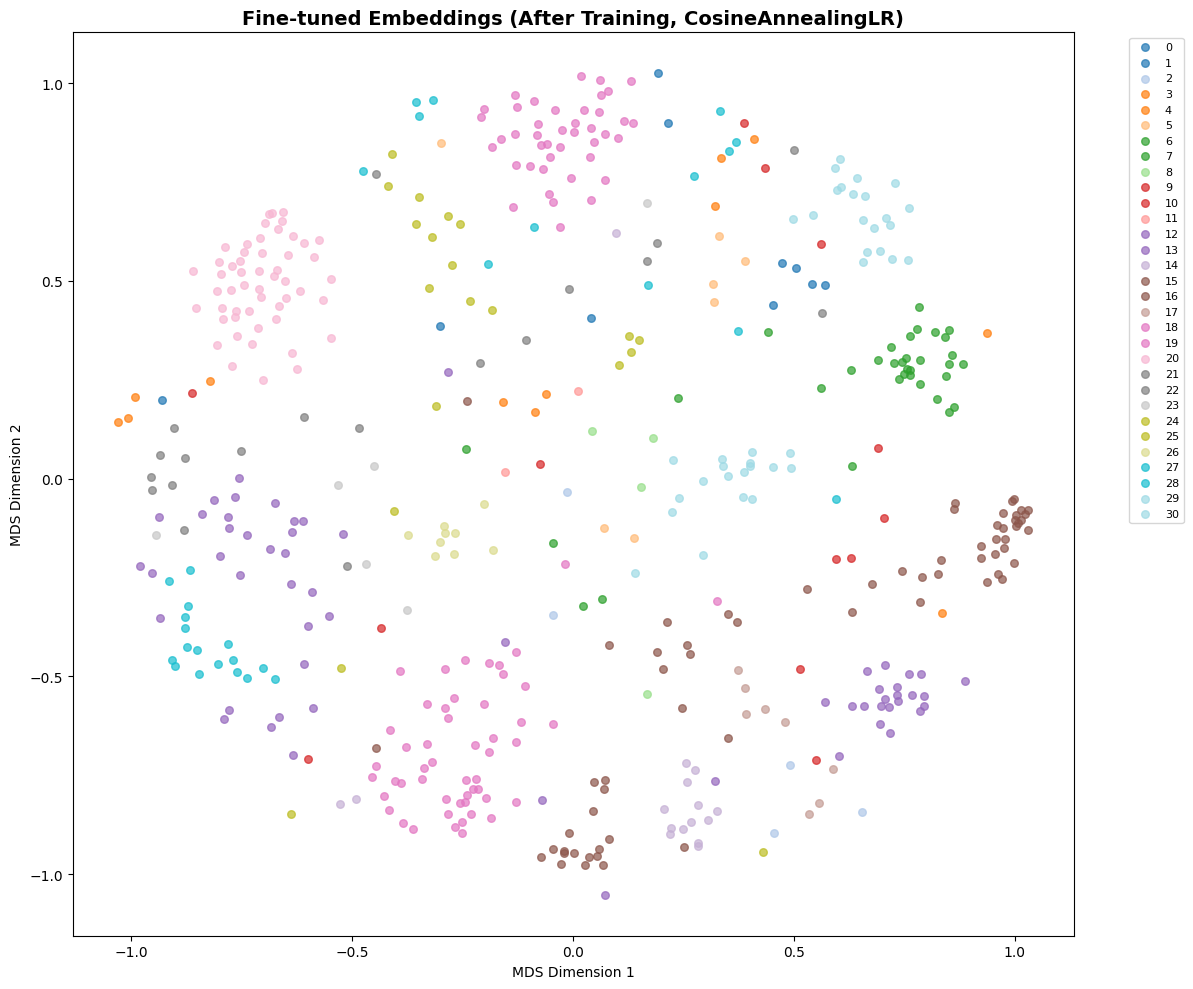

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, CosineAnnealingLR)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "cosineannealinglr_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_cosineannealinglr": wandb.Image(fig_finetuned)})

In [33]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## ReduceLROnPlateau

In [34]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["reduce_lr_on_plateau_init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["reduce_lr_on_plateau_factor"], 
    patience=config["reduce_lr_on_plateau_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['reduce_lr_on_plateau_init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['reduce_lr_on_plateau_factor']}, patience={config['reduce_lr_on_plateau_patience']})")

Training components initialized:
  Optimizer: AdamW (lr=0.0001, weight_decay=0.01)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [35]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_reduce_lr_on_plateau_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="reduce_lr_on_plateau",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_reduce_lr_on_plateau": best_map,
    "best_epoch_reduce_lr_on_plateau": best_epoch,
    "total_epochs_reduce_lr_on_plateau": len(history['train_loss']),
})

table.append([
    "ReduceLROnPlateau",
    best_map,
    best_epoch
])

All random seeds set to 234 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.5371
  Val Loss:   7.8710
  Val mAP:    0.3410 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 8.8576
  Val Loss:   7.5923
  Val mAP:    0.3472 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.4728
  Val Loss:   7.3827
  Val mAP:    0.3525 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.1793
  Val Loss:   7.1276
  Val mAP:    0.3558 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.2889
  Val Loss:   0.7451
  Val mAP:    0.9019 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 118/200


  Train Loss: 0.2642
  Val Loss:   0.7524
  Val mAP:    0.9057 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 119/200


  Train Loss: 0.2619
  Val Loss:   0.7623
  Val mAP:    0.9046 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 120/200


  Train Loss: 0.2617
  Val Loss:   0.7481
  Val mAP:    0.9049 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 121/200


  Train Loss: 0.2606
  Val Loss:   0.7475
  Val mAP:    0.9031 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 121 epochs

Training complete!
Best epoch: 111, Val mAP: 0.9074


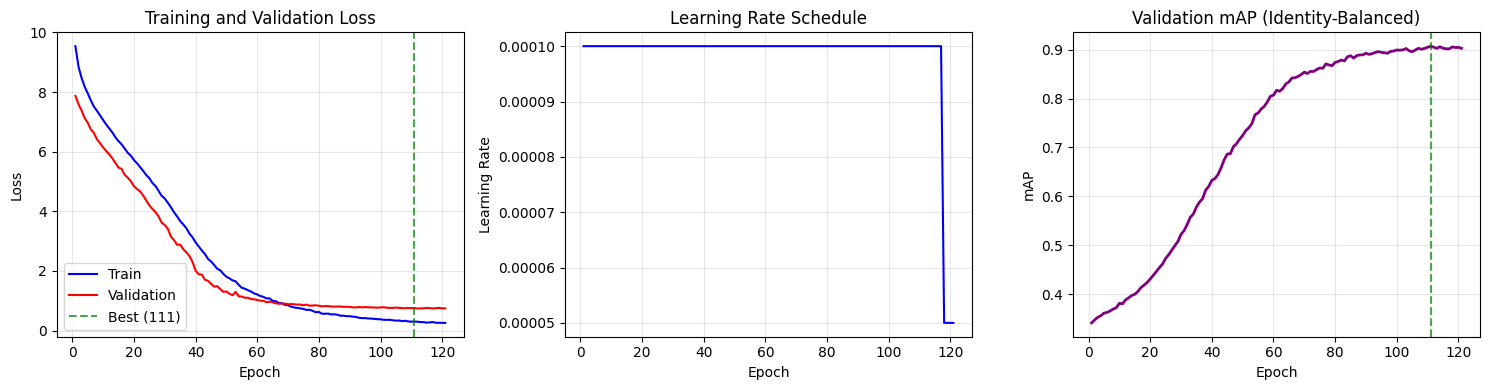

In [36]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_reduce_lr_on_plateau.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_reduce_lr_on_plateau": wandb.Image(fig)})

In [37]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 111
  Val Loss: 0.7593
  Val mAP: 0.9074


In [38]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


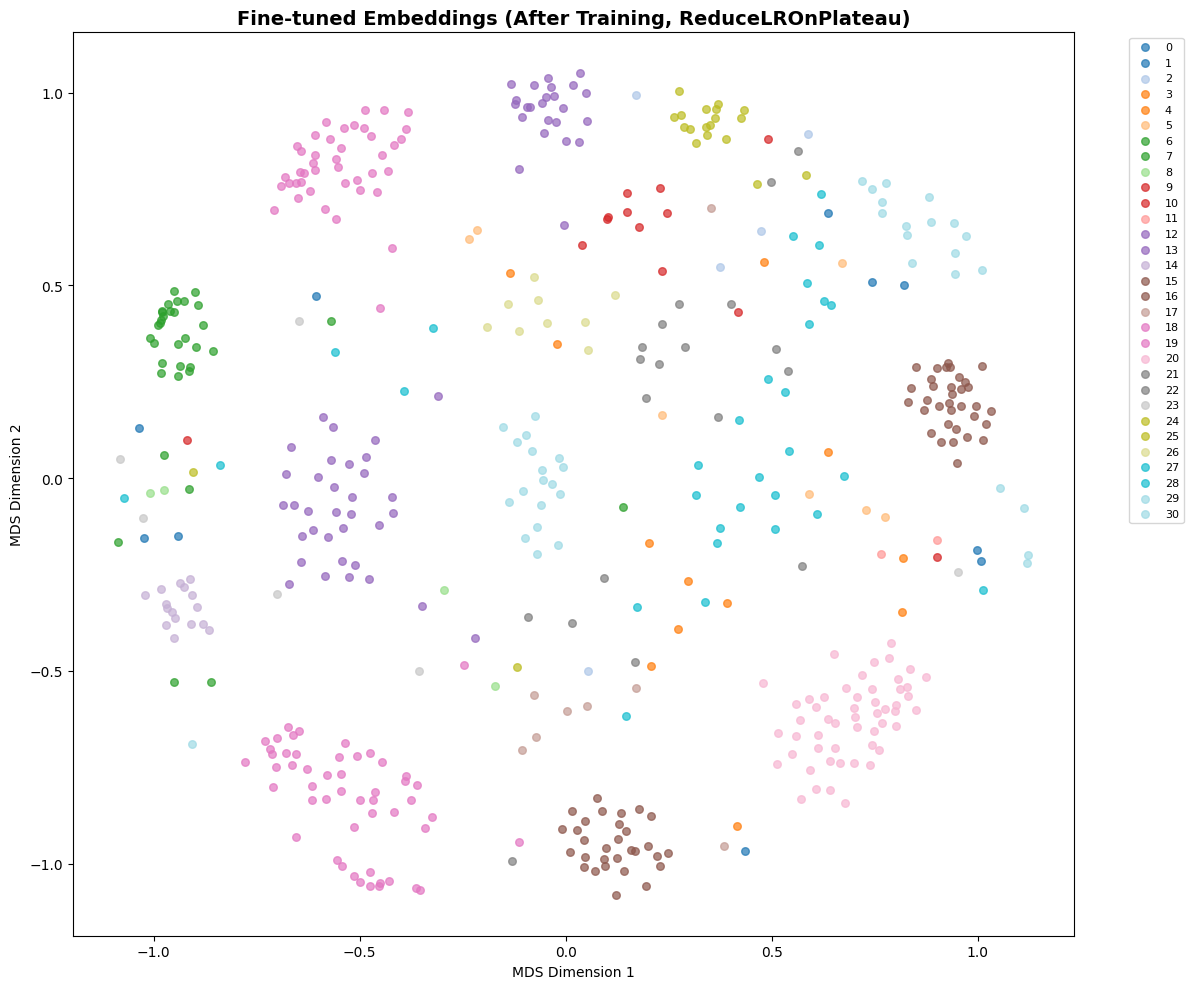

In [39]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, ReduceLROnPlateau)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "reduce_lr_on_plateau_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_reduce_lr_on_plateau": wandb.Image(fig_finetuned)})

In [40]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## ExponentialLR

In [41]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["exponential_lr_init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=config["exponential_lr_gamma"]
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['exponential_lr_init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ExponentialLR (gamma={config['exponential_lr_gamma']})")

Training components initialized:
  Optimizer: AdamW (lr=0.01, weight_decay=0.01)
  Scheduler: ExponentialLR (gamma=0.95)


In [42]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_exponential_lr_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="exponential_lr",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_exponential_lr": best_map,
    "best_epoch_exponential_lr": best_epoch,
    "total_epochs_exponential_lr": len(history['train_loss']),
})

table.append([
    "ExponentialLR",
    best_map,
    best_epoch
])

All random seeds set to 234 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 7.9636
  Val Loss:   2.0946
  Val mAP:    0.2609 | LR: 9.50e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 4.2307
  Val Loss:   1.9089
  Val mAP:    0.3769 | LR: 9.03e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.9922
  Val Loss:   1.5771
  Val mAP:    0.5115 | LR: 8.57e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 2.1493
  Val Loss:   1.4050
  Val mAP:    0.6550 | LR: 8.15e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.0958
  Val Loss:   0.6465
  Val mAP:    0.9037 | LR: 1.94e-03
  No improvement. Patience: 6/10

Epoch 33/200


  Train Loss: 0.0996
  Val Loss:   0.6622
  Val mAP:    0.9016 | LR: 1.84e-03
  No improvement. Patience: 7/10

Epoch 34/200


  Train Loss: 0.0919
  Val Loss:   0.6482
  Val mAP:    0.9085 | LR: 1.75e-03
  No improvement. Patience: 8/10

Epoch 35/200


  Train Loss: 0.0890
  Val Loss:   0.6408
  Val mAP:    0.9111 | LR: 1.66e-03
  No improvement. Patience: 9/10

Epoch 36/200


  Train Loss: 0.0885
  Val Loss:   0.6459
  Val mAP:    0.9100 | LR: 1.58e-03
  No improvement. Patience: 10/10

Early stopping triggered after 36 epochs

Training complete!
Best epoch: 26, Val mAP: 0.9145


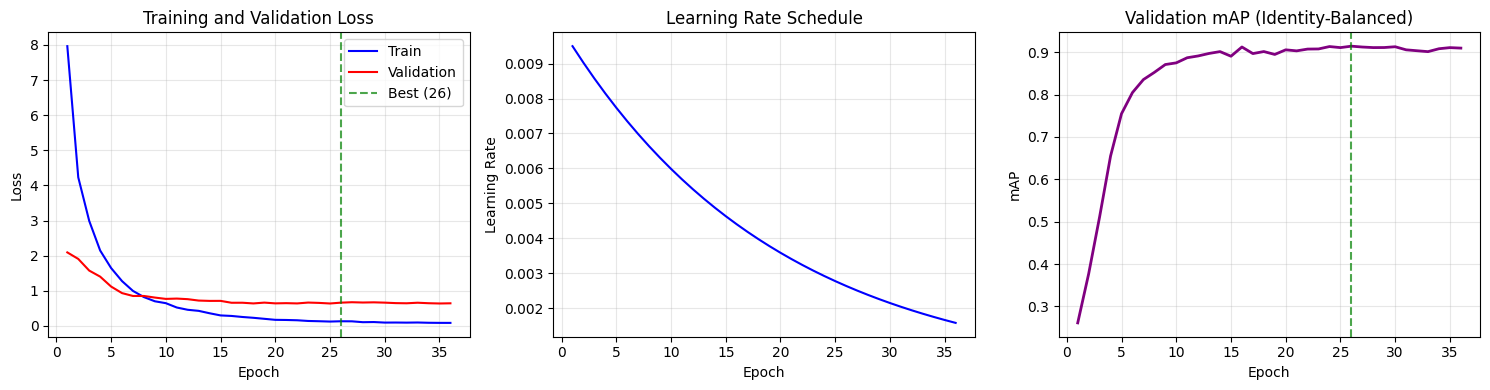

In [43]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_exponential_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_exponential_lr": wandb.Image(fig)})

In [44]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 26
  Val Loss: 0.6644
  Val mAP: 0.9145


In [45]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


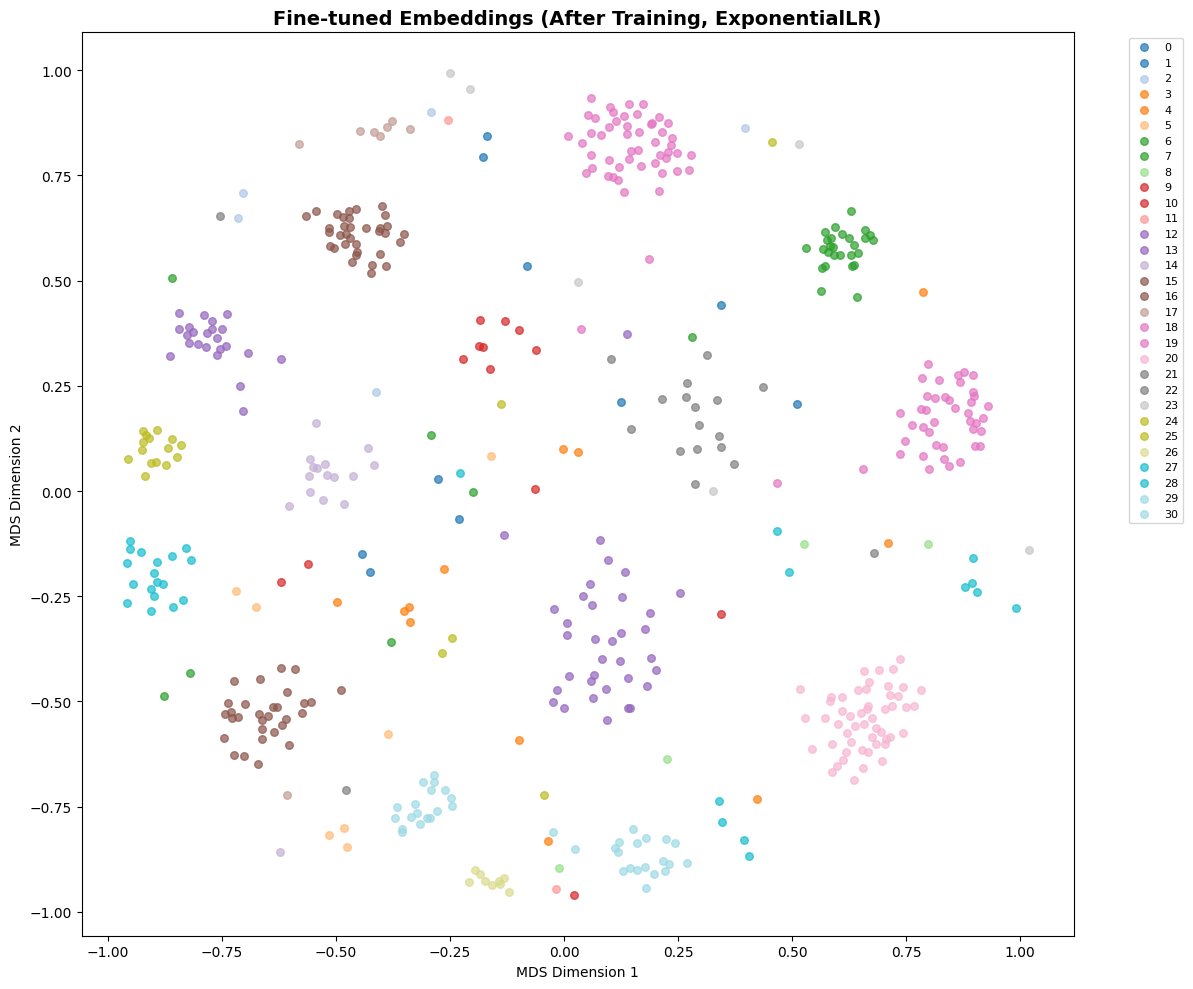

In [46]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, ExponentialLR)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "exponential_lr_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_exponential_lr": wandb.Image(fig_finetuned)})

In [47]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## OneCycleLR

In [48]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["one_cycle_init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config["one_cycle_max_learning_rate"],
    epochs=config["num_epochs"],
    steps_per_epoch=len(baseline_emb_train_loader),
    pct_start=config["one_cycle_pct_start"],
    anneal_strategy='cos',
    cycle_momentum=False,
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['one_cycle_init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: OneCycleLR (max_lr={config['one_cycle_max_learning_rate']}, epochs={config['num_epochs']}, steps_per_epoch={len(baseline_emb_train_loader)}, pct_start={config['one_cycle_pct_start']})")

Training components initialized:
  Optimizer: AdamW (lr=5e-05, weight_decay=0.01)
  Scheduler: OneCycleLR (max_lr=0.001, epochs=200, steps_per_epoch=48, pct_start=0.3)


In [49]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_one_cycle_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="one_cycle",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_one_cycle": best_map,
    "best_epoch_one_cycle": best_epoch,
    "total_epochs_one_cycle": len(history['train_loss']),
})

table.append([
    "OneCycleLR",
    best_map,
    best_epoch
])

All random seeds set to 234 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.5120
  Val Loss:   8.1849
  Val mAP:    0.3350 | LR: 4.07e-05
  [New best model saved]

Epoch 2/200


  Train Loss: 9.1962
  Val Loss:   7.9574
  Val mAP:    0.3398 | LR: 4.27e-05
  [New best model saved]

Epoch 3/200


  Train Loss: 8.9188
  Val Loss:   7.8618
  Val mAP:    0.3426 | LR: 4.62e-05
  [New best model saved]

Epoch 4/200


  Train Loss: 8.7308
  Val Loss:   7.6259
  Val mAP:    0.3422 | LR: 5.09e-05
  No improvement. Patience: 1/10

Epoch 5/200


...

  Train Loss: 0.0946
  Val Loss:   0.6830
  Val mAP:    0.8977 | LR: 9.77e-04
  No improvement. Patience: 6/10

Epoch 73/200


  Train Loss: 0.0953
  Val Loss:   0.7275
  Val mAP:    0.8963 | LR: 9.74e-04
  No improvement. Patience: 7/10

Epoch 74/200


  Train Loss: 0.0985
  Val Loss:   0.7141
  Val mAP:    0.9002 | LR: 9.70e-04
  No improvement. Patience: 8/10

Epoch 75/200


  Train Loss: 0.1008
  Val Loss:   0.7142
  Val mAP:    0.8977 | LR: 9.66e-04
  No improvement. Patience: 9/10

Epoch 76/200


  Train Loss: 0.1236
  Val Loss:   0.7007
  Val mAP:    0.8993 | LR: 9.61e-04
  No improvement. Patience: 10/10

Early stopping triggered after 76 epochs

Training complete!
Best epoch: 66, Val mAP: 0.9117


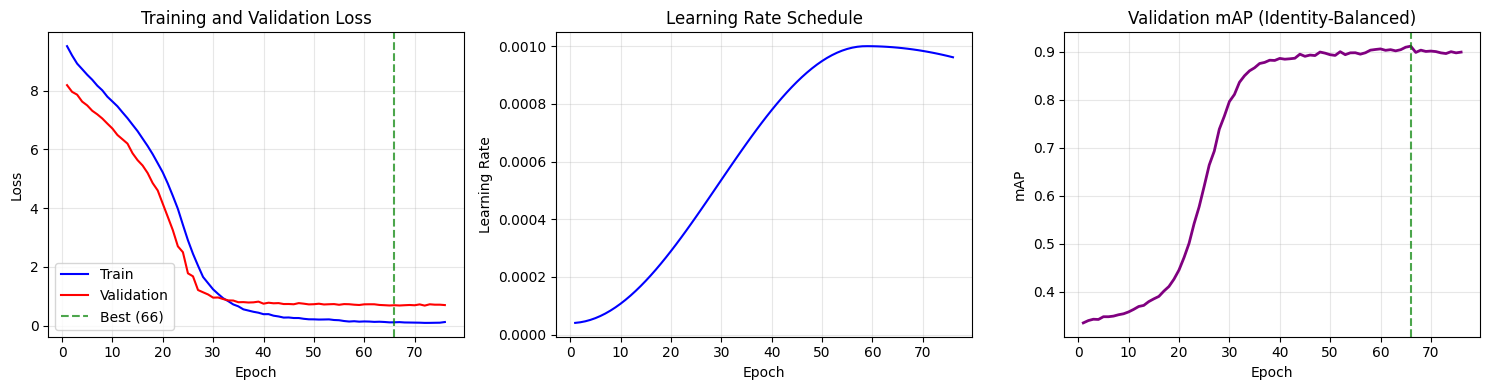

In [50]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_one_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_one_cycle": wandb.Image(fig)})

In [51]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 66
  Val Loss: 0.6957
  Val mAP: 0.9117


In [52]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


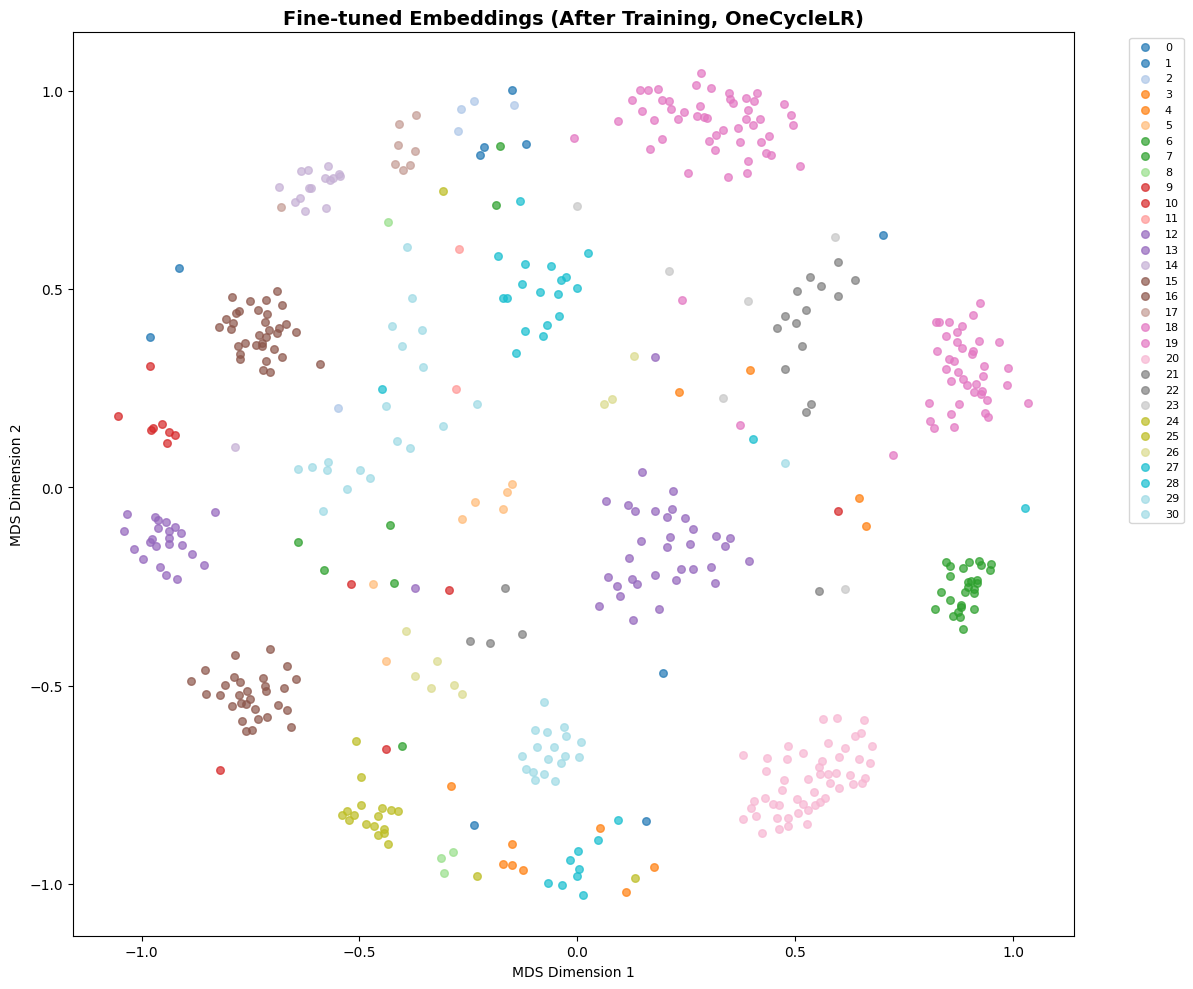

In [53]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training, OneCycleLR)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "one_cycle_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_one_cycle": wandb.Image(fig_finetuned)})

In [54]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [55]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+--------------+-----------+---------------------+---------------------+-----------------+--------------+
| Optimizer    |    StepLR |   CosineAnnealingLR |   ReduceLROnPlateau |   ExponentialLR |   OneCycleLR |
+==============+===========+=====================+=====================+=================+==============+
| Best val_mAP |  0.898404 |            0.902704 |            0.907385 |        0.914545 |     0.911662 |
+--------------+-----------+---------------------+---------------------+-----------------+--------------+
| Best epoch   | 30        |            8        |          111        |       26        |    66        |
+--------------+-----------+---------------------+---------------------+-----------------+--------------+


Result with random seed 34:
| Optimizer        | StepLR   | CosineAnnealingLR | ReduceLROnPlateau | ExponentialLR | OneCycleLR |
|-----------------|----------|-----------------|------------------|---------------|------------|
| Best val_mAP    | 0.859178 | 0.862013        | 0.843525         | 0.869651      | 0.852479   |
| Best epoch      | 32       | 31              | 99               | 57            | 41         |

Result with random seed 46:
| Optimizer        | StepLR   | CosineAnnealingLR | ReduceLROnPlateau | ExponentialLR | OneCycleLR |
|-----------------|----------|-----------------|------------------|---------------|------------|
| Best val_mAP    | 0.866516 | 0.876433        | 0.849911         | 0.874884      | 0.867874   |
| Best epoch      | 37       | 38              | 128              | 43            | 69         |

Result with random seed 78:
| Optimizer     | StepLR   | CosineAnnealingLR | ReduceLROnPlateau | ExponentialLR | OneCycleLR |
|---------------|----------|--------------------|-------------------|---------------|------------|
| Best val_mAP  | 0.875399 | 0.892876           | 0.863266          | 0.8878        | 0.875016   |
| Best epoch    | 15       | 38                 | 126               | 42            | 66         |

Result with random seed 98:
| Optimizer     | StepLR   | CosineAnnealingLR | ReduceLROnPlateau | ExponentialLR | OneCycleLR |
|---------------|----------|--------------------|--------------------|---------------|------------|
| Best val_mAP  | 0.880198 | 0.893288           | 0.843884           | 0.891809      | 0.88172    |
| Best epoch    | 31       | 27                 | 94                 | 32            | 69         |

Result with random seed 234:
| Optimizer     | StepLR   | CosineAnnealingLR | ReduceLROnPlateau | ExponentialLR | OneCycleLR |
|---------------|----------|--------------------|--------------------|---------------|------------|
| Best val_mAP  | 0.898404 | 0.902704           | 0.907385           | 0.914545      | 0.911662   |
| Best epoch    | 30       | 8                  | 111                | 26            | 66         |

| Optimizer         | Seed 34  | Seed 46  | Seed 78  | Seed 98  | Seed 234 | Mean     | Std      |
| ----------------- | -------- | -------- | -------- | -------- | -------- | -------- | -------- |
| ExponentialLR     | 0.869651 | 0.874884 | 0.887800 | 0.891809 | 0.914545 | 0.887538 | 0.018424 |
| CosineAnnealingLR | 0.862013 | 0.876433 | 0.892876 | 0.893288 | 0.902704 | 0.885463 | 0.014989 |
| OneCycleLR        | 0.852479 | 0.867874 | 0.875016 | 0.881720 | 0.911662 | 0.877550 | 0.020145 |
| StepLR            | 0.859178 | 0.866516 | 0.875399 | 0.880198 | 0.898404 | 0.875539 | 0.015249 |
| ReduceLROnPlateau | 0.843525 | 0.849911 | 0.863266 | 0.843884 | 0.907385 | 0.861594 | 0.023764 |


## Submission

In [56]:
checkpoint = torch.load(CHECKPOINT_PATH / "best_cosineannealinglr_model.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [57]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [58]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(test_image_paths, dino_preprocess),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    dino,
    test_loader,
    device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:00<00:00,  5.04s/it]

Test embeddings shape: (371, 768)


In [59]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [60]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 30803.16it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9989
  Mean: 0.3701
  Std: 0.1417


In [61]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.829578
1       1    0.324804
2       2    0.676782
3       3    0.424608
4       4    0.476591
5       5    0.528796
6       6    0.428708
7       7    0.491763
8       8    0.380679
9       9    0.378675

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [62]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/scheduler/submission.csv
File size: 2258.0 KB
